# Canonical Correlation Analysis: Player Mechanics vs Ball Parameters

Canonical Correlation Analysis (CCA) is a multivariate statistical technique that finds the linear combinations of two sets of variables (here, player body mechanics and ball movement parameters) that are maximally correlated with each other, allowing us to identify which joint and movement patterns most strongly co-vary with ball behavior and shot outcome.

## Analysis Objectives:
1. Map player mechanics variables to ball outcome parameters
2. Identify which variables make the biggest difference on ball movement
3. Analyze relationship with shot success (Made/Miss)
4. Group analysis by shot type and court location
5. Filter for players with 20+ shots to reduce bias
6. Analyze by movement phases (Pre-Hitch, Hitch, Post-Hitch)
7. Account for player identity effects

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from sklearn.impute import SimpleImputer
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load data
df = pd.read_csv('capstone2026.csv')
print(f"Data shape: {df.shape}")
print(f"\nColumns: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")
print(f"\nFirst few rows:")
df.head()

Data shape: (25868, 262)

Columns: 262
Rows: 25868

First few rows:


,Name,Date,Shot.Type,Shot.Location,Shot.Distance,Shot.X.Pos,Shot.Y.Pos,Made,Ball_Depth,left_right,...,timeToMaxElbowExtensionLeftHitch,timeToMaxElbowExtensionRightHitch,maxElbowExtensionLeftPostHitch,maxElbowExtensionRightPostHitch,maxElbowExtensionAvgPostHitch,timeToMaxElbowExtensionLeftPostHitch,timeToMaxElbowExtensionRightPostHitch,ElbowTotalROMRight,ElbowTotalROMLeft,PlayerID
0,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.324880,-22.323844,-0.215156,False,22.61,-2.18,...,0.475,0.475,16.8562,22.3653,19.6107,0.650,0.650,-81.4055,-122.0768,Player 1
1,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.507735,-22.507038,-0.177118,True,12.96,-3.84,...,0.392,0.392,10.1352,23.7183,16.9268,0.567,0.559,-78.7364,-119.9664,Player 1
2,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.798792,-22.797181,-0.270969,True,14.14,-1.73,...,0.384,0.350,13.4128,21.6987,17.5557,0.559,0.550,-81.1395,-124.8665,Player 1
3,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.980568,-22.977321,-0.386303,False,6.61,-2.44,...,0.342,0.317,13.1956,24.0487,18.6222,0.525,0.517,-75.8957,-120.4512,Player 1
4,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.559167,-22.556121,-0.370699,True,15.83,-0.41,...,0.266,0.250,14.6284,22.8648,18.7466,0.441,0.433,-80.9099,-118.7658,Player 1


## 2. Data Preprocessing

In [3]:
# Check for missing values
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Top 20 columns with missing values:")
print(missing_pct[missing_pct > 0].head(20))

print(f"\nShot Type distribution:")
print(df['Shot.Type'].value_counts())

print(f"\nShot Location distribution:")
print(df['Shot.Location'].value_counts())

Top 20 columns with missing values:
Series([], dtype: float64)

Shot Type distribution:
Shot.Type
Off the Dribble    13614
Catch and Shoot    12254
Name: count, dtype: int64

Shot Location distribution:
Shot.Location
Middle Three          5004
Left Corner Three     4990
Right Corner Three    4958
Free Throw            3967
Key                   1820
Left Wing Three       1568
Right Wing Three      1436
Middle Two             602
Left Corner Two        596
Right Corner Two       525
Left Wing Two          204
Right Wing Two         198
Name: count, dtype: int64


In [4]:
# Filter players with 20+ shots
shot_counts = df.groupby('Name').size()
players_20plus = shot_counts[shot_counts >= 20].index

df_filtered = df[df['Name'].isin(players_20plus)].copy()

print(f"Original dataset: {len(df)} shots from {df['Name'].nunique()} players")
print(f"Filtered dataset: {len(df_filtered)} shots from {df_filtered['Name'].nunique()} players")
print(f"\nShots per player (filtered):")
print(df_filtered.groupby('Name').size().describe())

Original dataset: 25868 shots from 165 players
Filtered dataset: 25686 shots from 143 players

Shots per player (filtered):
count     143.000000
mean      179.622378
std       328.492905
min        20.000000
25%        88.000000
50%       104.000000
75%       154.500000
max      3045.000000
dtype: float64


## 3. Define Variable Groups

In [5]:
# Ball parameters (outcome variables)
ball_params = [
    'Ball_Depth', 'left_right', 'Ball.Distance.from.Center', 'Ball_to_Rim_Angle',
    'Ball_Velocity', 'Release.Height', 'Initial.Ball.Angle', 'Initial.Ball.Velocity',
    'Starting.Ball.Height', 'Max.Ball.Arc'
]

# Timing variables
timing_vars = [
    'TotalShotTime', 'Pre.Hitch.Time', 'Hitch.Time', 'Post.Hitch.Time',
    'PercTimePreHitch', 'PercTimeHitch', 'PercTimePostHitch'
]

# Torso and alignment variables
torso_alignment_vars = [
    'TorsoVeloPreHitch', 'TorsoVeloHitch', 'TorsoVeloPostHitch', 'TorsoVeloRelease',
    'ShoulderAlignmentPreHitch', 'ShoulderAlignmentHitch', 'ShoulderAlignmentPostHitch', 'ShoulderAlignmentRelease',
    'HipAlignmentPreHitch', 'HipAlignmentHitch', 'HipAlignmentPostHitch', 'HipAlignmentRelease',
    'FeetAlignmentPreHitch', 'FeetAlignmentHitch', 'FeetAlignmentPostHitch', 'FeetAlignmentRelease',
    'TorsoFlexionAtT0', 'maxTorsoFlexionPreHitch', 'maxTorsoFlexionHitch', 'maxTorsoFlexionPostHitch',
    'maxTorsoExtensionPreHitch', 'maxTorsoExtensionHitch', 'maxTorsoExtensionPostHitch', 'TorsoTotalROMAvg'
]

# Ball position and distance variables
ball_position_vars = [
    'MaxBallDist_PreHitch', 'MaxBallDist_Hitch', 'MaxBallDist_PostHitch',
    'Max.Ball.Cocked', 'Max.Ball.Released..Away.from.body.', 'Delta.Ball.Cocked.vs.Release',
    'BallVeloStart', 'BallVeloPreHitch', 'BallVeloPostHitch', 'BallVeloRelease'
]

# Stance variables
stance_vars = [
    'MaxStanceGapPreHitch', 'MaxStanceGapHitch', 'MaxStanceGapPostHitch', 'MaxStanceGapRelease'
]

# Lower body joint variables by phase
ankle_vars = [col for col in df_filtered.columns if 'Ankle' in col or 'ankle' in col]
knee_vars = [col for col in df_filtered.columns if 'Knee' in col or 'knee' in col]
hip_vars = [col for col in df_filtered.columns if 'Hip' in col and 'hip' in col and 'Hitch' not in col]

# Upper body joint variables
shoulder_vars = [col for col in df_filtered.columns if 'Shoulder' in col and 'shoulder' in col and 'Alignment' not in col]
elbow_vars = [col for col in df_filtered.columns if 'Elbow' in col or 'elbow' in col]

# Combine all player mechanics variables
player_mechanics = (timing_vars + torso_alignment_vars + ball_position_vars + 
                    stance_vars + ankle_vars + knee_vars + hip_vars + 
                    shoulder_vars + elbow_vars)

# Remove duplicates and ensure all columns exist
player_mechanics = list(set(player_mechanics))
player_mechanics = [col for col in player_mechanics if col in df_filtered.columns]

print(f"Ball parameters: {len(ball_params)}")
print(f"Player mechanics variables: {len(player_mechanics)}")
print(f"\nVariable groups:")
print(f"  - Timing: {len(timing_vars)}")
print(f"  - Torso/Alignment: {len(torso_alignment_vars)}")
print(f"  - Ball Position: {len(ball_position_vars)}")
print(f"  - Stance: {len(stance_vars)}")
print(f"  - Ankle: {len(ankle_vars)}")
print(f"  - Knee: {len(knee_vars)}")
print(f"  - Hip: {len(hip_vars)}")
print(f"  - Shoulder: {len(shoulder_vars)}")
print(f"  - Elbow: {len(elbow_vars)}")

Ball parameters: 10
Player mechanics variables: 143

Variable groups:
  - Timing: 7
  - Torso/Alignment: 24
  - Ball Position: 10
  - Stance: 4
  - Ankle: 32
  - Knee: 32
  - Hip: 0
  - Shoulder: 0
  - Elbow: 34


## 4. Phase-Specific Variable Groups

Following Eric's suggestion to analyze by movement phases

In [6]:
# Pre-Hitch phase variables
pre_hitch_vars = [col for col in player_mechanics if 'PreHitch' in col or 'Pre.Hitch' in col or 'AtT0' in col]

# Hitch phase variables
hitch_vars = [col for col in player_mechanics if 'Hitch' in col and 'Pre' not in col and 'Post' not in col]

# Post-Hitch phase variables
post_hitch_vars = [col for col in player_mechanics if 'PostHitch' in col or 'Post.Hitch' in col or 'Release' in col]

print(f"Pre-Hitch variables: {len(pre_hitch_vars)}")
print(f"Hitch variables: {len(hitch_vars)}")
print(f"Post-Hitch variables: {len(post_hitch_vars)}")

Pre-Hitch variables: 46
Hitch variables: 40
Post-Hitch variables: 49


## 5. Helper Functions for CCA Analysis

In [7]:
def prepare_cca_data(data, player_vars, ball_vars, min_valid_pct=0.5):
    """
    Prepare data for CCA by handling missing values and scaling.
    
    Parameters:
    -----------
    data : DataFrame
        Input data
    player_vars : list
        Player mechanics variable names
    ball_vars : list
        Ball parameter variable names
    min_valid_pct : float
        Minimum percentage of valid (non-missing) values required for a variable
    
    Returns:
    --------
    X_scaled, Y_scaled : arrays
        Scaled player and ball variable arrays
    valid_player_vars, valid_ball_vars : lists
        Variables that passed the validity check
    """
    # Filter variables with sufficient data
    valid_player_vars = []
    for var in player_vars:
        if var in data.columns:
            valid_pct = data[var].notna().sum() / len(data)
            if valid_pct >= min_valid_pct:
                valid_player_vars.append(var)
    
    valid_ball_vars = []
    for var in ball_vars:
        if var in data.columns:
            valid_pct = data[var].notna().sum() / len(data)
            if valid_pct >= min_valid_pct:
                valid_ball_vars.append(var)
    
    if len(valid_player_vars) == 0 or len(valid_ball_vars) == 0:
        return None, None, [], []
    
    # Extract data
    X = data[valid_player_vars].copy()
    Y = data[valid_ball_vars].copy()
    
    # Impute missing values with median
    imputer_X = SimpleImputer(strategy='median')
    imputer_Y = SimpleImputer(strategy='median')
    
    X_imputed = imputer_X.fit_transform(X)
    Y_imputed = imputer_Y.fit_transform(Y)
    
    # Scale the data
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
    
    X_scaled = scaler_X.fit_transform(X_imputed)
    Y_scaled = scaler_Y.fit_transform(Y_imputed)
    
    return X_scaled, Y_scaled, valid_player_vars, valid_ball_vars


def run_cca_analysis(X, Y, X_vars, Y_vars, n_components=None):
    """
    Run canonical correlation analysis.
    
    Parameters:
    -----------
    X, Y : arrays
        Scaled input arrays
    X_vars, Y_vars : lists
        Variable names
    n_components : int
        Number of canonical components (default: min of X and Y dimensions)
    
    Returns:
    --------
    cca : CCA object
        Fitted CCA model
    correlations : array
        Canonical correlations
    X_c, Y_c : arrays
        Canonical variates
    """
    if n_components is None:
        n_components = min(X.shape[1], Y.shape[1], X.shape[0] - 1)
        n_components = min(n_components, 10)  # Limit to 10 components max
    
    # Fit CCA
    cca = CCA(n_components=n_components, max_iter=1000)
    cca.fit(X, Y)
    
    # Transform data to canonical space
    X_c, Y_c = cca.transform(X, Y)
    
    # Calculate canonical correlations
    correlations = [np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1] for i in range(n_components)]
    
    return cca, correlations, X_c, Y_c


def get_variable_loadings(cca, X_vars, Y_vars, X_scaled, Y_scaled, X_c, Y_c, n_top=10):
    """
    Calculate and return the most important variables for each canonical variate.
    
    Returns:
    --------
    loadings_df : DataFrame
        Variable loadings for each canonical component
    """
    n_components = X_c.shape[1]
    
    results = []
    
    for i in range(n_components):
        # Correlations between original variables and canonical variates (loadings)
        X_loadings = [np.corrcoef(X_scaled[:, j], X_c[:, i])[0, 1] for j in range(len(X_vars))]
        Y_loadings = [np.corrcoef(Y_scaled[:, j], Y_c[:, i])[0, 1] for j in range(len(Y_vars))]
        
        # Get top player mechanics variables
        X_loading_pairs = list(zip(X_vars, X_loadings))
        X_loading_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
        
        # Get top ball parameter variables
        Y_loading_pairs = list(zip(Y_vars, Y_loadings))
        Y_loading_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
        
        results.append({
            'component': i + 1,
            'top_player_vars': X_loading_pairs[:n_top],
            'top_ball_vars': Y_loading_pairs[:n_top]
        })
    
    return results


def plot_cca_results(correlations, loadings, title_prefix=""):
    """
    Visualize CCA results.
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot canonical correlations
    axes[0].bar(range(1, len(correlations) + 1), correlations, color='steelblue', alpha=0.7)
    axes[0].set_xlabel('Canonical Component', fontsize=12)
    axes[0].set_ylabel('Canonical Correlation', fontsize=12)
    axes[0].set_title(f'{title_prefix}Canonical Correlations', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Plot top variable loadings for first component
    if len(loadings) > 0:
        top_player = loadings[0]['top_player_vars'][:5]
        top_ball = loadings[0]['top_ball_vars'][:5]
        
        player_names = [v[0][:30] for v in top_player]  # Truncate long names
        player_vals = [v[1] for v in top_player]
        
        ball_names = [v[0][:30] for v in top_ball]
        ball_vals = [v[1] for v in top_ball]
        
        x = np.arange(5)
        width = 0.35
        
        axes[1].barh(x - width/2, player_vals, width, label='Player Mechanics', alpha=0.7, color='coral')
        axes[1].barh(x + width/2, ball_vals, width, label='Ball Parameters', alpha=0.7, color='skyblue')
        axes[1].set_yticks(x)
        axes[1].set_yticklabels([f"Var {i+1}" for i in range(5)])
        axes[1].set_xlabel('Loading', fontsize=12)
        axes[1].set_title(f'{title_prefix}Top 5 Variable Loadings (Component 1)', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Helper functions defined successfully!")

Helper functions defined successfully!


## 6. Overall CCA Analysis (All Shots)

First, run CCA on all data to get a baseline understanding

In [8]:
# Prepare data for overall analysis
X_all, Y_all, valid_player_all, valid_ball_all = prepare_cca_data(
    df_filtered, player_mechanics, ball_params, min_valid_pct=0.6
)

print(f"Valid player mechanics variables: {len(valid_player_all)}")
print(f"Valid ball parameter variables: {len(valid_ball_all)}")
print(f"Sample size: {len(X_all)}")

Valid player mechanics variables: 143
Valid ball parameter variables: 10
Sample size: 25686


In [9]:
# Run CCA on all data
if X_all is not None and Y_all is not None:
    cca_all, corr_all, X_c_all, Y_c_all = run_cca_analysis(
        X_all, Y_all, valid_player_all, valid_ball_all
    )
    
    print("Overall CCA Results:")
    print("=" * 50)
    for i, corr in enumerate(corr_all):
        print(f"Canonical Correlation {i+1}: {corr:.4f}")
    
    # Get variable loadings
    loadings_all = get_variable_loadings(
        cca_all, valid_player_all, valid_ball_all, 
        X_all, Y_all, X_c_all, Y_c_all
    )
    
    # Display top variables for first 3 components
    for comp_result in loadings_all[:3]:
        comp_num = comp_result['component']
        print(f"\n{'='*50}")
        print(f"Canonical Component {comp_num}")
        print(f"{'='*50}")
        print("\nTop Player Mechanics Variables:")
        for var, loading in comp_result['top_player_vars'][:10]:
            print(f"  {var:50s} {loading:7.4f}")
        
        print("\nTop Ball Parameter Variables:")
        for var, loading in comp_result['top_ball_vars'][:10]:
            print(f"  {var:50s} {loading:7.4f}")

Overall CCA Results:
Canonical Correlation 1: 0.9369
Canonical Correlation 2: 0.9053
Canonical Correlation 3: 0.8726
Canonical Correlation 4: 0.6854
Canonical Correlation 5: 0.4692
Canonical Correlation 6: 0.4193
Canonical Correlation 7: 0.3176
Canonical Correlation 8: 0.2280
Canonical Correlation 9: 0.2030
Canonical Correlation 10: 0.1489

Canonical Component 1

Top Player Mechanics Variables:
  BallVeloRelease                                     0.7785
  TorsoVeloPostHitch                                  0.7494
  BallVeloPreHitch                                    0.7254
  ankleTotalROMAvg                                   -0.6929
  maxAnklePlantarflexionLeftPostHitch                -0.6634
  KneeTotalROMAvg                                     0.6561
  maxAnklePlantarflexionAvgPostHitch                 -0.6535
  BallVeloPostHitch                                   0.6468
  maxKneeFlexionAvgHitch                             -0.6314
  maxKneeFlexionAvgPreHitch                          

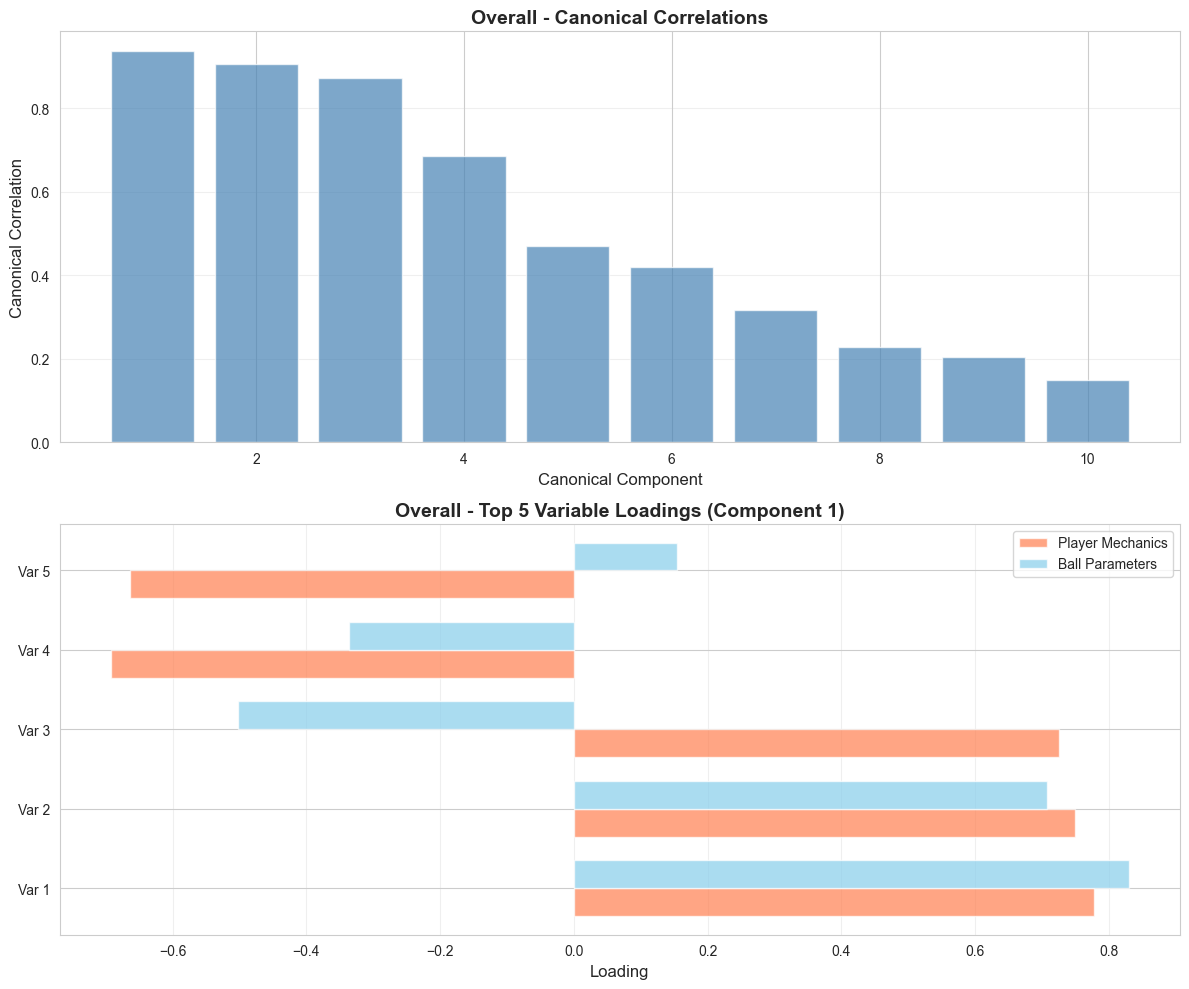

In [11]:
# Visualize overall results
if X_all is not None:
    plot_cca_results(corr_all, loadings_all, title_prefix="Overall - ")

## 7. CCA by Shot Type and Location

Following Eric's recommendation to analyze each shot type and location separately

In [12]:
# Get unique shot types and locations
shot_types = df_filtered['Shot.Type'].unique()
shot_locations = df_filtered['Shot.Location'].unique()

print(f"Shot Types: {shot_types}")
print(f"\nShot Locations: {shot_locations}")

# Count samples for each combination
print("\nSample sizes for each combination:")
for shot_type in shot_types:
    for location in shot_locations:
        count = len(df_filtered[(df_filtered['Shot.Type'] == shot_type) & 
                                 (df_filtered['Shot.Location'] == location)])
        if count > 0:
            print(f"  {shot_type:20s} + {location:20s}: {count:5d} shots")

Shot Types: ['Off the Dribble' 'Catch and Shoot']

Shot Locations: ['Left Corner Three' 'Right Corner Three' 'Middle Three' 'Free Throw'
 'Key' 'Right Corner Two' 'Left Corner Two' 'Right Wing Two'
 'Right Wing Three' 'Left Wing Two' 'Left Wing Three' 'Middle Two']

Sample sizes for each combination:
  Off the Dribble      + Left Corner Three   :  3958 shots
  Off the Dribble      + Right Corner Three  :  2317 shots
  Off the Dribble      + Middle Three        :   713 shots
  Off the Dribble      + Free Throw          :  3423 shots
  Off the Dribble      + Key                 :  1287 shots
  Off the Dribble      + Right Corner Two    :   223 shots
  Off the Dribble      + Left Corner Two     :   327 shots
  Off the Dribble      + Right Wing Two      :    95 shots
  Off the Dribble      + Right Wing Three    :   378 shots
  Off the Dribble      + Left Wing Two       :    86 shots
  Off the Dribble      + Left Wing Three     :   544 shots
  Off the Dribble      + Middle Two          :   

In [14]:
# Store results for each shot type + location combination
cca_results = {}

min_samples = 50  # Minimum sample size for reliable CCA

for shot_type in shot_types:
    for location in shot_locations:
        # Filter data
        mask = (df_filtered['Shot.Type'] == shot_type) & (df_filtered['Shot.Location'] == location)
        data_subset = df_filtered[mask]
        
        if len(data_subset) < min_samples:
            continue
        
        key = f"{shot_type}_{location}"
        print(f"\n{'='*70}")
        print(f"Analyzing: {shot_type} at {location}")
        print(f"{'='*70}")
        print(f"Sample size: {len(data_subset)}")
        
        # Prepare data
        X, Y, valid_X_vars, valid_Y_vars = prepare_cca_data(
            data_subset, player_mechanics, ball_params, min_valid_pct=0.5
        )
        
        if X is None or len(valid_X_vars) < 5 or len(valid_Y_vars) < 3:
            print(f"  Skipping: insufficient valid variables")
            continue
        
        print(f"  Valid player variables: {len(valid_X_vars)}")
        print(f"  Valid ball variables: {len(valid_Y_vars)}")
        
        # Run CCA
        try:
            cca, corr, X_c, Y_c = run_cca_analysis(X, Y, valid_X_vars, valid_Y_vars)
            loadings = get_variable_loadings(cca, valid_X_vars, valid_Y_vars, X, Y, X_c, Y_c)
            
            # Store results
            cca_results[key] = {
                'shot_type': shot_type,
                'location': location,
                'n_samples': len(data_subset),
                'cca': cca,
                'correlations': corr,
                'loadings': loadings,
                'X_vars': valid_X_vars,
                'Y_vars': valid_Y_vars
            }
            
            # Print top results
            print(f"\n  Top 3 Canonical Correlations: {corr[:3]}")
            
            print("\n  Top 5 Player Variables (Component 1):")
            for var, loading in loadings[0]['top_player_vars'][:5]:
                print(f"    {var:45s} {loading:7.4f}")
            
            print("\n  Top 5 Ball Variables (Component 1):")
            for var, loading in loadings[0]['top_ball_vars'][:5]:
                print(f"    {var:45s} {loading:7.4f}")
                
        except Exception as e:
            print(f"  Error in CCA: {str(e)}")
            continue

print(f"\n\nCompleted CCA for {len(cca_results)} shot type + location combinations")


Analyzing: Off the Dribble at Left Corner Three
Sample size: 3958
  Valid player variables: 143
  Valid ball variables: 10

  Top 3 Canonical Correlations: [0.9474063129746038, 0.9192334495298897, 0.7687422902580919]

  Top 5 Player Variables (Component 1):
    timeToMaxElbowFlexionLeftPreHitch              0.7038
    timeToMaxKneeFlexionLeftPostHitch              0.6873
    timeToMaxAnkleDorsiflexionLeftPostHitch        0.6867
    timeToMaxKneeFlexionRightPostHitch             0.6865
    timeToMaxAnkleDorsiflexionRightPostHitch       0.6830

  Top 5 Ball Variables (Component 1):
    Ball_Velocity                                 -0.6987
    Starting.Ball.Height                          -0.6157
    Initial.Ball.Velocity                          0.1209
    Max.Ball.Arc                                  -0.0875
    Release.Height                                -0.0856

Analyzing: Off the Dribble at Right Corner Three
Sample size: 2317
  Valid player variables: 143
  Valid ball variables: 

## 8. Visualize CCA Results by Shot Type/Location

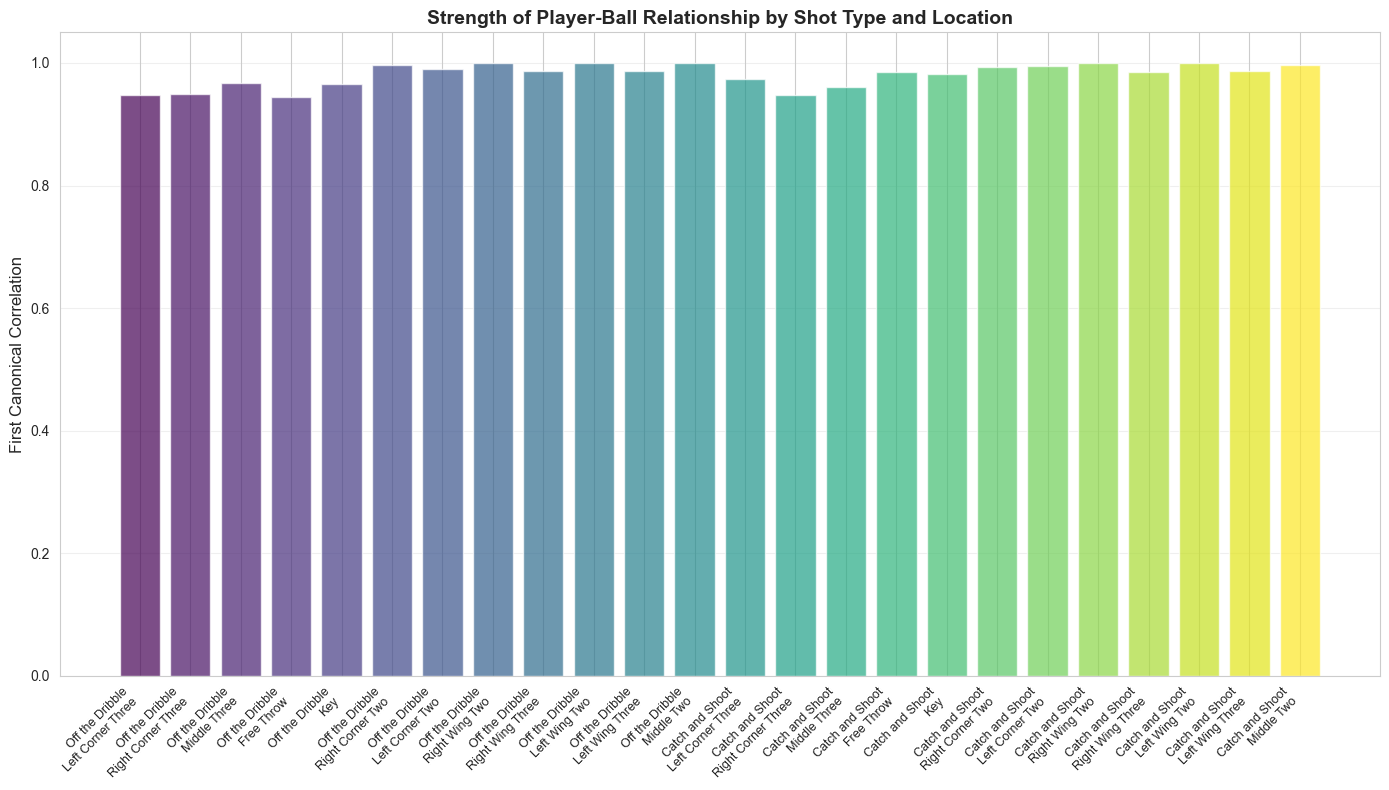

In [15]:
# Create summary visualization of canonical correlations
fig, ax = plt.subplots(figsize=(14, 8))

keys = list(cca_results.keys())
first_corrs = [cca_results[k]['correlations'][0] for k in keys]

colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))
bars = ax.bar(range(len(keys)), first_corrs, color=colors, alpha=0.7)

ax.set_xticks(range(len(keys)))
ax.set_xticklabels([k.replace('_', '\n') for k in keys], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('First Canonical Correlation', fontsize=12)
ax.set_title('Strength of Player-Ball Relationship by Shot Type and Location', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Compare top variables across shot types/locations
print("\n" + "="*80)
print("COMPARISON OF TOP VARIABLES ACROSS SHOT TYPES/LOCATIONS")
print("="*80)

# Collect all top player variables
all_player_vars = {}
for key, result in cca_results.items():
    for var, loading in result['loadings'][0]['top_player_vars'][:5]:
        if var not in all_player_vars:
            all_player_vars[var] = []
        all_player_vars[var].append((key, loading))

# Find variables that appear across multiple shot types
common_vars = {k: v for k, v in all_player_vars.items() if len(v) >= 2}

print(f"\nPlayer variables appearing in top 5 for multiple shot types ({len(common_vars)}):")
for var in sorted(common_vars.keys(), key=lambda x: len(common_vars[x]), reverse=True)[:15]:
    occurrences = common_vars[var]
    print(f"\n  {var}:")
    print(f"    Appears in {len(occurrences)} shot type/location combinations")
    avg_loading = np.mean([abs(loading) for _, loading in occurrences])
    print(f"    Average |loading|: {avg_loading:.4f}")


COMPARISON OF TOP VARIABLES ACROSS SHOT TYPES/LOCATIONS

Player variables appearing in top 5 for multiple shot types (30):

  BallVeloPreHitch:
    Appears in 8 shot type/location combinations
    Average |loading|: 0.7406

  TorsoVeloPostHitch:
    Appears in 7 shot type/location combinations
    Average |loading|: 0.6058

  timeToMaxElbowFlexionLeftPreHitch:
    Appears in 6 shot type/location combinations
    Average |loading|: 0.6595

  PercTimePreHitch:
    Appears in 5 shot type/location combinations
    Average |loading|: 0.7555

  timeToMaxAnkleDorsiflexionLeftPostHitch:
    Appears in 4 shot type/location combinations
    Average |loading|: 0.4727

  ElbowFlexionAtT0Right:
    Appears in 4 shot type/location combinations
    Average |loading|: 0.5430

  timeToMaxElbowFlexionRightPreHitch:
    Appears in 4 shot type/location combinations
    Average |loading|: 0.7033

  timeToMaxAnkleDorsiflexionRightPostHitch:
    Appears in 3 shot type/location combinations
    Average |load

## 9. CCA by Phase (Pre-Hitch, Hitch, Post-Hitch)

Following Eric's suggestion to analyze movement by phases

In [16]:
# Run phase-specific CCA for each shot type
phase_results = {}

for shot_type in shot_types:
    data_shot = df_filtered[df_filtered['Shot.Type'] == shot_type]
    
    if len(data_shot) < min_samples:
        continue
    
    print(f"\n{'='*70}")
    print(f"Phase Analysis for: {shot_type}")
    print(f"{'='*70}")
    print(f"Total samples: {len(data_shot)}")
    
    phase_vars_dict = {
        'Pre-Hitch': pre_hitch_vars,
        'Hitch': hitch_vars,
        'Post-Hitch': post_hitch_vars
    }
    
    for phase_name, phase_vars in phase_vars_dict.items():
        print(f"\n  {phase_name} Phase:")
        print(f"  {'-'*50}")
        
        # Prepare data
        X, Y, valid_X_vars, valid_Y_vars = prepare_cca_data(
            data_shot, phase_vars, ball_params, min_valid_pct=0.5
        )
        
        if X is None or len(valid_X_vars) < 5:
            print(f"    Skipping: insufficient variables ({len(valid_X_vars) if X is not None else 0})")
            continue
        
        print(f"    Valid player variables: {len(valid_X_vars)}")
        print(f"    Valid ball variables: {len(valid_Y_vars)}")
        
        try:
            # Run CCA
            cca, corr, X_c, Y_c = run_cca_analysis(X, Y, valid_X_vars, valid_Y_vars)
            loadings = get_variable_loadings(cca, valid_X_vars, valid_Y_vars, X, Y, X_c, Y_c)
            
            key = f"{shot_type}_{phase_name}"
            phase_results[key] = {
                'shot_type': shot_type,
                'phase': phase_name,
                'correlations': corr,
                'loadings': loadings
            }
            
            print(f"    First canonical correlation: {corr[0]:.4f}")
            print(f"\n    Top 3 Variables:")
            for var, loading in loadings[0]['top_player_vars'][:3]:
                print(f"      {var:40s} {loading:7.4f}")
                
        except Exception as e:
            print(f"    Error: {str(e)}")
            continue

print(f"\n\nCompleted phase analysis for {len(phase_results)} combinations")


Phase Analysis for: Off the Dribble
Total samples: 13491

  Pre-Hitch Phase:
  --------------------------------------------------
    Valid player variables: 46
    Valid ball variables: 10
    First canonical correlation: 0.8382

    Top 3 Variables:
      BallVeloPreHitch                          0.9315
      maxKneeFlexionAvgPreHitch                -0.6886
      maxKneeFlexionLeftPreHitch               -0.6641

  Hitch Phase:
  --------------------------------------------------
    Valid player variables: 40
    Valid ball variables: 10
    First canonical correlation: 0.7989

    Top 3 Variables:
      timeToMaxElbowExtensionRightHitch         0.7846
      timeToMaxElbowExtensionLeftHitch          0.7846
      timeToMaxKneeFlexionLeftHitch             0.7837

  Post-Hitch Phase:
  --------------------------------------------------
    Valid player variables: 49
    Valid ball variables: 10
    First canonical correlation: 0.9103

    Top 3 Variables:
      BallVeloRelease         

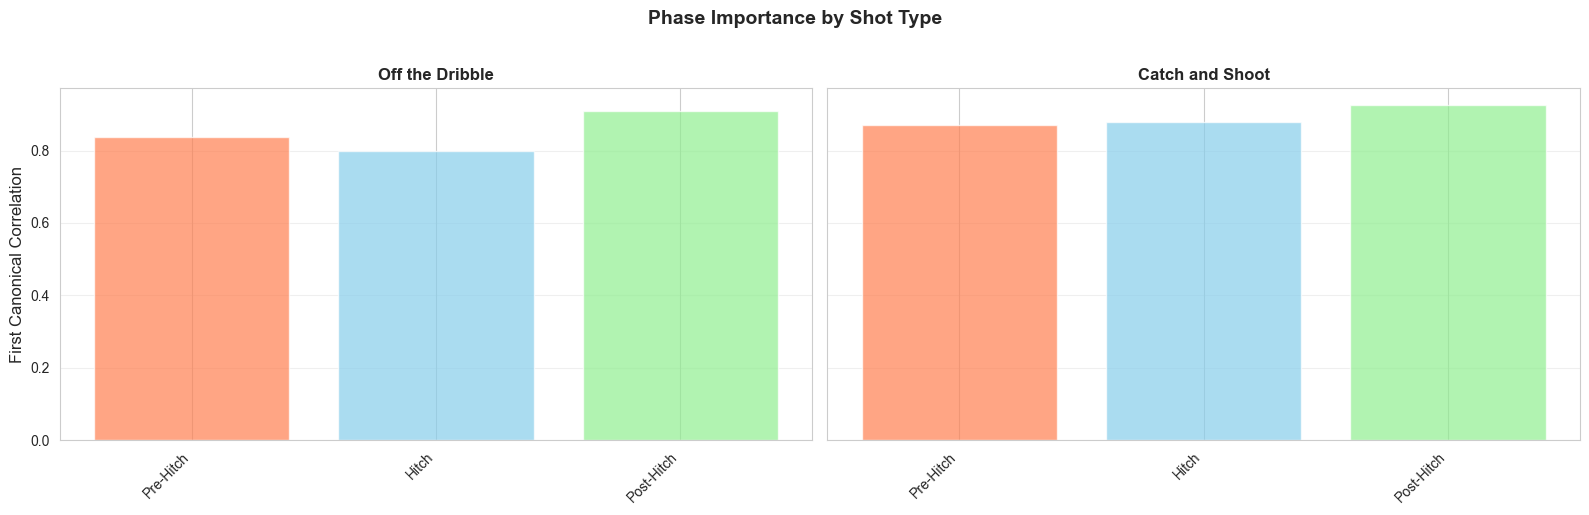

In [17]:
# Visualize phase importance across shot types
if len(phase_results) > 0:
    # Organize by shot type and phase
    shot_types_with_results = list(set([r['shot_type'] for r in phase_results.values()]))
    phases = ['Pre-Hitch', 'Hitch', 'Post-Hitch']
    
    fig, axes = plt.subplots(1, len(shot_types_with_results), figsize=(16, 5), sharey=True)
    if len(shot_types_with_results) == 1:
        axes = [axes]
    
    for idx, shot_type in enumerate(shot_types_with_results):
        phase_corrs = []
        phase_labels = []
        
        for phase in phases:
            key = f"{shot_type}_{phase}"
            if key in phase_results:
                phase_corrs.append(phase_results[key]['correlations'][0])
                phase_labels.append(phase)
        
        if phase_corrs:
            axes[idx].bar(range(len(phase_corrs)), phase_corrs, 
                         color=['coral', 'skyblue', 'lightgreen'][:len(phase_corrs)], alpha=0.7)
            axes[idx].set_xticks(range(len(phase_labels)))
            axes[idx].set_xticklabels(phase_labels, rotation=45, ha='right')
            axes[idx].set_title(shot_type, fontsize=12, fontweight='bold')
            axes[idx].grid(axis='y', alpha=0.3)
    
    axes[0].set_ylabel('First Canonical Correlation', fontsize=12)
    fig.suptitle('Phase Importance by Shot Type', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 10. Relationship with Shot Success (Made vs. Missed)

Analyze how joint mechanics relate to whether the shot goes in

In [18]:
# Separate analysis for made vs missed shots
print("Shot Success Analysis")
print("="*70)

made_pct = df_filtered['Made'].mean()
print(f"Overall make percentage: {made_pct:.1%}")
print(f"Made shots: {df_filtered['Made'].sum()}")
print(f"Missed shots: {len(df_filtered) - df_filtered['Made'].sum()}")

# Analyze by shot type
print("\nMake percentage by shot type:")
for shot_type in shot_types:
    data_shot = df_filtered[df_filtered['Shot.Type'] == shot_type]
    if len(data_shot) > 0:
        make_pct = data_shot['Made'].mean()
        print(f"  {shot_type:30s}: {make_pct:.1%} ({data_shot['Made'].sum()}/{len(data_shot)})")

Shot Success Analysis
Overall make percentage: 65.4%
Made shots: 16807
Missed shots: 8879

Make percentage by shot type:
  Off the Dribble               : 68.0% (9176/13491)
  Catch and Shoot               : 62.6% (7631/12195)


In [19]:
# Compare mechanics between made and missed shots
from scipy.stats import ttest_ind

def compare_made_vs_missed(data, shot_type, variables, n_top=10):
    """
    Compare variable values between made and missed shots.
    """
    data_shot = data[data['Shot.Type'] == shot_type]
    made = data_shot[data_shot['Made'] == 1]
    missed = data_shot[data_shot['Made'] == 0]
    
    if len(made) < 10 or len(missed) < 10:
        return None
    
    results = []
    
    for var in variables:
        if var not in data.columns:
            continue
        
        made_vals = made[var].dropna()
        missed_vals = missed[var].dropna()
        
        if len(made_vals) < 5 or len(missed_vals) < 5:
            continue
        
        # T-test
        t_stat, p_val = ttest_ind(made_vals, missed_vals)
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt((made_vals.std()**2 + missed_vals.std()**2) / 2)
        if pooled_std > 0:
            cohens_d = (made_vals.mean() - missed_vals.mean()) / pooled_std
        else:
            cohens_d = 0
        
        results.append({
            'variable': var,
            'made_mean': made_vals.mean(),
            'missed_mean': missed_vals.mean(),
            'diff': made_vals.mean() - missed_vals.mean(),
            'p_value': p_val,
            'cohens_d': cohens_d
        })
    
    # Sort by effect size
    results.sort(key=lambda x: abs(x['cohens_d']), reverse=True)
    
    return results[:n_top]

# Run comparison for each shot type
success_results = {}

for shot_type in shot_types:
    print(f"\n{'='*70}")
    print(f"Made vs. Missed Analysis: {shot_type}")
    print(f"{'='*70}")
    
    results = compare_made_vs_missed(df_filtered, shot_type, player_mechanics, n_top=10)
    
    if results is None:
        print("Insufficient data")
        continue
    
    success_results[shot_type] = results
    
    print(f"\nTop 10 variables with largest differences (Made vs. Missed):")
    print(f"{'Variable':45s} {'Made Mean':>12s} {'Missed Mean':>12s} {'Diff':>10s} {'p-value':>10s} {'Cohens d':>10s}")
    print("-" * 105)
    
    for r in results:
        sig = "***" if r['p_value'] < 0.001 else "**" if r['p_value'] < 0.01 else "*" if r['p_value'] < 0.05 else ""
        print(f"{r['variable']:45s} {r['made_mean']:12.4f} {r['missed_mean']:12.4f} {r['diff']:10.4f} {r['p_value']:10.4f}{sig:3s} {r['cohens_d']:10.4f}")


Made vs. Missed Analysis: Off the Dribble

Top 10 variables with largest differences (Made vs. Missed):
Variable                                         Made Mean  Missed Mean       Diff    p-value   Cohens d
---------------------------------------------------------------------------------------------------------
ankleTotalROMAvg                                  -42.1607     -46.6180     4.4574     0.0000***     0.3645
maxAnklePlantarflexionLeftPostHitch               -16.8673     -20.9070     4.0397     0.0000***     0.3541
maxAnklePlantarflexionAvgPostHitch                -17.2290     -21.0439     3.8149     0.0000***     0.3488
maxAnklePlantarflexionRightPostHitch              -17.5907     -21.1807     3.5901     0.0000***     0.3243
TorsoVeloRelease                                    0.5922       0.7470    -0.1549     0.0000***    -0.3169
KneeTotalROMAvg                                    47.0971      51.6666    -4.5695     0.0000***    -0.3143
TorsoVeloPostHitch                  

## 11. Player-Level Analysis

Following Abhijit's suggestion to analyze metrics by individual players

In [20]:
# Analyze player-specific patterns
print("Player-Level Analysis")
print("="*70)

# Calculate player statistics
player_stats = df_filtered.groupby('Name').agg({
    'Made': ['sum', 'count', 'mean'],
    'Shot.Type': lambda x: x.mode()[0] if len(x.mode()) > 0 else None,
    'Shot.Location': lambda x: x.mode()[0] if len(x.mode()) > 0 else None
}).round(3)

player_stats.columns = ['Made', 'Total_Shots', 'Make_Pct', 'Primary_Shot_Type', 'Primary_Location']
player_stats = player_stats.sort_values('Make_Pct', ascending=False)

print(f"\nPlayer Performance Summary (Top 15):")
print(player_stats.head(15))

print(f"\nPlayer Performance Summary (Bottom 15):")
print(player_stats.tail(15))

Player-Level Analysis

Player Performance Summary (Top 15):
            Made  Total_Shots  Make_Pct Primary_Shot_Type    Primary_Location
Name                                                                         
Player 106    52           59     0.881   Catch and Shoot          Middle Two
Player 32     96          109     0.881   Off the Dribble          Free Throw
Player 87     77           89     0.865   Off the Dribble          Free Throw
Player 30     30           35     0.857   Off the Dribble   Left Corner Three
Player 27     86          102     0.843   Catch and Shoot   Left Corner Three
Player 60     56           67     0.836   Off the Dribble   Left Corner Three
Player 18     82           99     0.828   Off the Dribble   Left Corner Three
Player 165    78           95     0.821   Off the Dribble        Middle Three
Player 90     85          104     0.817   Catch and Shoot        Middle Three
Player 156   104          128     0.812   Off the Dribble  Right Corner Three
Play

In [21]:
# Identify stand-out mechanical patterns for top performers
top_players = player_stats.nlargest(10, 'Make_Pct').index
bottom_players = player_stats.nsmallest(10, 'Make_Pct').index

top_data = df_filtered[df_filtered['Name'].isin(top_players)]
bottom_data = df_filtered[df_filtered['Name'].isin(bottom_players)]

print("\nComparing Top vs. Bottom Performers")
print("="*70)
print(f"Top 10 players: {len(top_data)} shots, {top_data['Made'].mean():.1%} make rate")
print(f"Bottom 10 players: {len(bottom_data)} shots, {bottom_data['Made'].mean():.1%} make rate")

# Find mechanical differences
mechanical_diffs = []

for var in player_mechanics:
    if var not in df_filtered.columns:
        continue
    
    top_vals = top_data[var].dropna()
    bottom_vals = bottom_data[var].dropna()
    
    if len(top_vals) < 10 or len(bottom_vals) < 10:
        continue
    
    t_stat, p_val = ttest_ind(top_vals, bottom_vals)
    
    pooled_std = np.sqrt((top_vals.std()**2 + bottom_vals.std()**2) / 2)
    if pooled_std > 0:
        cohens_d = (top_vals.mean() - bottom_vals.mean()) / pooled_std
    else:
        cohens_d = 0
    
    mechanical_diffs.append({
        'variable': var,
        'top_mean': top_vals.mean(),
        'bottom_mean': bottom_vals.mean(),
        'diff': top_vals.mean() - bottom_vals.mean(),
        'p_value': p_val,
        'cohens_d': cohens_d
    })

mechanical_diffs.sort(key=lambda x: abs(x['cohens_d']), reverse=True)

print(f"\nTop 15 Mechanical Differences (Top vs. Bottom Performers):")
print(f"{'Variable':45s} {'Top Mean':>12s} {'Bottom Mean':>12s} {'Diff':>10s} {'p-value':>10s} {'Cohens d':>10s}")
print("-" * 105)

for r in mechanical_diffs[:15]:
    sig = "***" if r['p_value'] < 0.001 else "**" if r['p_value'] < 0.01 else "*" if r['p_value'] < 0.05 else ""
    print(f"{r['variable']:45s} {r['top_mean']:12.4f} {r['bottom_mean']:12.4f} {r['diff']:10.4f} {r['p_value']:10.4f}{sig:3s} {r['cohens_d']:10.4f}")


Comparing Top vs. Bottom Performers
Top 10 players: 887 shots, 84.1% make rate
Bottom 10 players: 957 shots, 40.6% make rate

Top 15 Mechanical Differences (Top vs. Bottom Performers):
Variable                                          Top Mean  Bottom Mean       Diff    p-value   Cohens d
---------------------------------------------------------------------------------------------------------
maxElbowFlexionRightHitch                         122.0688     108.8535    13.2153     0.0000***     1.0659
maxKneeExtensionLeftPreHitch                      -62.8265     -50.9796   -11.8470     0.0000***    -0.9187
maxElbowFlexionAvgHitch                           114.0236     104.9082     9.1155     0.0000***     0.9180
maxKneeExtensionAvgPreHitch                       -63.2881     -51.6667   -11.6214     0.0000***    -0.8817
TorsoVeloPostHitch                                  1.3749       0.8296     0.5453     0.0000***     0.8758
MaxBallDist_PreHitch                                0.5459     

## 12. Dimension Reduction with PCA

Following Abhijit's suggestion to use PCA to identify patterns

PCA Analysis on Player Mechanics

Explained Variance Ratio:
  PC1: 0.2836 (Cumulative: 0.2836)
  PC2: 0.1137 (Cumulative: 0.3973)
  PC3: 0.0965 (Cumulative: 0.4938)
  PC4: 0.0538 (Cumulative: 0.5476)
  PC5: 0.0489 (Cumulative: 0.5964)
  PC6: 0.0395 (Cumulative: 0.6359)
  PC7: 0.0322 (Cumulative: 0.6681)
  PC8: 0.0301 (Cumulative: 0.6982)
  PC9: 0.0279 (Cumulative: 0.7261)
  PC10: 0.0232 (Cumulative: 0.7493)


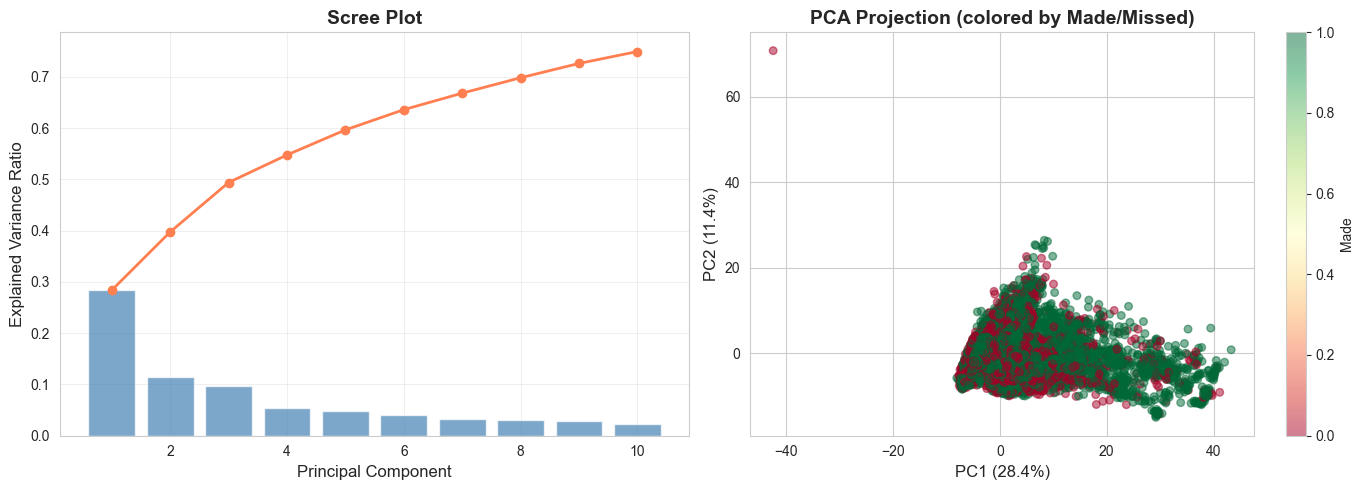

In [22]:
# Apply PCA to player mechanics variables
print("PCA Analysis on Player Mechanics")
print("="*70)

# Prepare data for PCA
X_pca, _, valid_vars_pca, _ = prepare_cca_data(
    df_filtered, player_mechanics, ball_params, min_valid_pct=0.6
)

if X_pca is not None:
    # Run PCA
    pca = PCA(n_components=min(10, X_pca.shape[1]))
    X_pca_transformed = pca.fit_transform(X_pca)
    
    # Explained variance
    print(f"\nExplained Variance Ratio:")
    for i, var in enumerate(pca.explained_variance_ratio_):
        cum_var = pca.explained_variance_ratio_[:i+1].sum()
        print(f"  PC{i+1}: {var:.4f} (Cumulative: {cum_var:.4f})")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scree plot
    axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
                pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
    axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1),
                 np.cumsum(pca.explained_variance_ratio_), 'o-', color='coral', linewidth=2)
    axes[0].set_xlabel('Principal Component', fontsize=12)
    axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
    axes[0].set_title('Scree Plot', fontsize=14, fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # PC1 vs PC2 colored by make percentage
    scatter = axes[1].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1],
                             c=df_filtered['Made'], cmap='RdYlGn', alpha=0.5, s=30)
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
    axes[1].set_title('PCA Projection (colored by Made/Missed)', fontsize=14, fontweight='bold')
    plt.colorbar(scatter, ax=axes[1], label='Made')
    
    plt.tight_layout()
    plt.show()

In [26]:
# PC loadings - which variables contribute most to each PC
if X_pca is not None:
    print("\nPrincipal Component Loadings")
    print("="*70)
    
    for i in range(min(3, pca.n_components_)):
        print(f"\nPC{i+1} (explains {pca.explained_variance_ratio_[i]:.1%} of variance):")
        print(f"{'-'*70}")
        
        # Get loadings
        loadings = pca.components_[i]
        loading_pairs = list(zip(valid_vars_pca, loadings))
        loading_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
        
        print("Top 10 positive loadings:")
        for var, loading in loading_pairs[:10]:
            if loading > 0:
                print(f"  {var:50s} {loading:7.4f}")
        
        print("\nTop 10 negative loadings:")
        for var, loading in sorted(loading_pairs, key=lambda x: x[1])[:10]:
            if loading < 0:
                print(f"  {var:50s} {loading:7.4f}")


Principal Component Loadings

PC1 (explains 28.4% of variance):
----------------------------------------------------------------------
Top 10 positive loadings:
  timeToMaxKneeFlexionRightPostHitch                  0.1541
  timeToMaxKneeFlexionLeftPostHitch                   0.1541
  timeToMaxAnkleDorsiflexionLeftPostHitch             0.1539
  timeToMaxElbowExtensionRightHitch                   0.1539
  timeToMaxAnkleDorsiflexionRightPostHitch            0.1538
  timeToMaxKneeExtensionRightHitch                    0.1538
  timeToMaxElbowFlexionLeftPostHitch                  0.1537
  timeToMaxKneeExtensionLeftHitch                     0.1537
  timeToMaxElbowExtensionLeftHitch                    0.1537
  timeToMaxAnklePlantarflexionRightHitch              0.1537

Top 10 negative loadings:
  KneeTotalROMAvg                                    -0.0649
  TorsoVeloRelease                                   -0.0637
  BallVeloRelease                                    -0.0590
  maxAnkleDorsifle

In [23]:
# Analyze PCA components by shot type
if X_pca is not None:
    df_with_pca = df_filtered.copy()
    for i in range(pca.n_components_):
        df_with_pca[f'PC{i+1}'] = X_pca_transformed[:, i]
    
    print("\nPCA Components by Shot Type")
    print("="*70)
    
    for shot_type in shot_types:
        data_shot = df_with_pca[df_with_pca['Shot.Type'] == shot_type]
        if len(data_shot) < 20:
            continue
        
        print(f"\n{shot_type}:")
        for i in range(min(3, pca.n_components_)):
            pc_col = f'PC{i+1}'
            made_mean = data_shot[data_shot['Made'] == 1][pc_col].mean()
            missed_mean = data_shot[data_shot['Made'] == 0][pc_col].mean()
            print(f"  {pc_col}: Made={made_mean:7.4f}, Missed={missed_mean:7.4f}, Diff={made_mean-missed_mean:7.4f}")


PCA Components by Shot Type

Off the Dribble:
  PC1: Made= 1.9568, Missed= 0.0240, Diff= 1.9327
  PC2: Made= 0.8442, Missed= 0.3715, Diff= 0.4727
  PC3: Made= 0.4708, Missed=-0.3762, Diff= 0.8470

Catch and Shoot:
  PC1: Made=-1.2624, Missed=-1.8461, Diff= 0.5838
  PC2: Made=-0.5929, Missed=-1.0573, Diff= 0.4644
  PC3: Made=-0.2249, Missed=-0.2148, Diff=-0.0101


## 13. Using CCA to Predict Shot Success

Now we connect player mechanics → ball parameters → shot success to answer: **Which joint variables are most important for making shots?**

In [24]:
# Step 1: Analyze which ball parameters predict Made
print("BALL PARAMETERS → SHOT SUCCESS")
print("="*70)

from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, classification_report

ball_made_results = {}

for shot_type in shot_types:
    for location in shot_locations:
        mask = (df_filtered['Shot.Type'] == shot_type) & (df_filtered['Shot.Location'] == location)
        data_subset = df_filtered[mask]
        
        if len(data_subset) < 50:
            continue
        
        # Prepare ball parameters
        X_ball = data_subset[ball_params].copy()
        y = data_subset['Made'].values
        
        # Handle missing values
        imputer = SimpleImputer(strategy='median')
        X_ball_imputed = imputer.fit_transform(X_ball)
        
        # Scale
        scaler = StandardScaler()
        X_ball_scaled = scaler.fit_transform(X_ball_imputed)
        
        # Fit logistic regression
        lr = LogisticRegressionCV(cv=5, random_state=42, max_iter=1000, scoring='roc_auc')
        lr.fit(X_ball_scaled, y)
        
        # Predictions
        y_pred_proba = lr.predict_proba(X_ball_scaled)[:, 1]
        auc = roc_auc_score(y, y_pred_proba)
        
        # Store coefficients
        coefs = list(zip(ball_params, lr.coef_[0]))
        coefs.sort(key=lambda x: abs(x[1]), reverse=True)
        
        key = f"{shot_type}_{location}"
        ball_made_results[key] = {
            'shot_type': shot_type,
            'location': location,
            'auc': auc,
            'n_samples': len(data_subset),
            'make_rate': y.mean(),
            'coefficients': coefs
        }
        
        print(f"\n{key}")
        print(f"  AUC: {auc:.3f}, Make Rate: {y.mean():.1%}, N={len(data_subset)}")
        print(f"  Top 3 ball predictors:")
        for var, coef in coefs[:3]:
            direction = "↑ increases" if coef > 0 else "↓ decreases"
            print(f"    {var:30s}: {coef:7.4f} ({direction} make probability)")

print(f"\n\nAnalyzed {len(ball_made_results)} shot type/location combinations")

BALL PARAMETERS → SHOT SUCCESS

Off the Dribble_Left Corner Three
  AUC: 0.967, Make Rate: 63.1%, N=3958
  Top 3 ball predictors:
    Ball.Distance.from.Center     : -5.2594 (↓ decreases make probability)
    Ball_Depth                    :  3.2338 (↑ increases make probability)
    left_right                    :  0.3551 (↑ increases make probability)

Off the Dribble_Right Corner Three
  AUC: 0.980, Make Rate: 61.6%, N=2317
  Top 3 ball predictors:
    Ball.Distance.from.Center     : -6.3406 (↓ decreases make probability)
    Ball_Depth                    :  2.0723 (↑ increases make probability)
    left_right                    : -0.7930 (↓ decreases make probability)

Off the Dribble_Middle Three
  AUC: 0.972, Make Rate: 47.1%, N=713
  Top 3 ball predictors:
    Ball.Distance.from.Center     : -4.1392 (↓ decreases make probability)
    Ball_Depth                    :  0.6605 (↑ increases make probability)
    Ball_Velocity                 :  0.2523 (↑ increases make probability)

O

In [27]:
# Step 2: Use CCA canonical variates to predict Made
print("\n" + "="*70)
print("PLAYER MECHANICS (via CCA) → SHOT SUCCESS")
print("="*70)

cca_made_results = {}

for key, result in cca_results.items():
    data_subset = df_filtered[
        (df_filtered['Shot.Type'] == result['shot_type']) & 
        (df_filtered['Shot.Location'] == result['location'])
    ]
    
    # Prepare data
    X, Y, valid_X_vars, valid_Y_vars = prepare_cca_data(
        data_subset, player_mechanics, ball_params, min_valid_pct=0.5
    )
    
    if X is None:
        continue
    
    y = data_subset['Made'].values
    
    # Get CCA model from previous analysis
    cca = result['cca']
    
    # Transform to canonical space
    X_c, Y_c = cca.transform(X, Y)
    
    # Use canonical variates to predict Made
    lr = LogisticRegressionCV(cv=5, random_state=42, max_iter=1000, scoring='roc_auc')
    lr.fit(X_c, y)
    
    y_pred_proba = lr.predict_proba(X_c)[:, 1]
    auc = roc_auc_score(y, y_pred_proba)
    
    # Get most important canonical components
    component_importance = list(zip(range(1, len(lr.coef_[0]) + 1), lr.coef_[0]))
    component_importance.sort(key=lambda x: abs(x[1]), reverse=True)
    
    cca_made_results[key] = {
        'shot_type': result['shot_type'],
        'location': result['location'],
        'auc': auc,
        'n_samples': len(data_subset),
        'make_rate': y.mean(),
        'component_importance': component_importance,
        'cca_result': result
    }
    
    print(f"\n{key}")
    print(f"  AUC: {auc:.3f}, Make Rate: {y.mean():.1%}")
    print(f"  Most important canonical components:")
    for comp_num, coef in component_importance[:3]:
        direction = "↑ increases" if coef > 0 else "↓ decreases"
        print(f"    Component {comp_num}: {coef:7.4f} ({direction} make probability)")
        # Show top player variables from this component
        top_vars = result['loadings'][comp_num-1]['top_player_vars'][:3]
        print(f"      Driven by: {', '.join([v[0][:30] for v in top_vars])}")

print(f"\n\nTotal groups analyzed: {len(cca_made_results)}")


PLAYER MECHANICS (via CCA) → SHOT SUCCESS

Off the Dribble_Left Corner Three
  AUC: 0.528, Make Rate: 63.1%
  Most important canonical components:
    Component 1: -0.0000 (↓ decreases make probability)
      Driven by: timeToMaxElbowFlexionLeftPreHi, timeToMaxKneeFlexionLeftPostHi, timeToMaxAnkleDorsiflexionLeft
    Component 8:  0.0000 (↑ increases make probability)
      Driven by: MaxStanceGapPreHitch, MaxBallDist_PreHitch, maxAnklePlantarflexionRightPos
    Component 6:  0.0000 (↑ increases make probability)
      Driven by: BallVeloRelease, TorsoVeloPostHitch, maxAnklePlantarflexionAvgPreHi

Off the Dribble_Right Corner Three
  AUC: 0.562, Make Rate: 61.6%
  Most important canonical components:
    Component 4:  0.0000 (↑ increases make probability)
      Driven by: BallVeloRelease, MaxBallDist_PreHitch, Post.Hitch.Time
    Component 10: -0.0000 (↓ decreases make probability)
      Driven by: BallVeloPostHitch, ankleFlexionAtT0Avg, maxAnkleDorsiflexionLeftHitch
    Component 2: 

In [28]:
# Step 3: Synthesize the pathway - which player mechanics → ball params → shot success
print("\n" + "="*70)
print("COMPLETE PATHWAY: PLAYER MECHANICS → BALL PARAMETERS → MADE")
print("="*70)

pathway_results = []

for key in cca_made_results.keys():
    if key not in ball_made_results:
        continue
    
    cca_res = cca_made_results[key]
    ball_res = ball_made_results[key]
    cca_data = cca_res['cca_result']
    
    # Get the most important canonical component for predicting Made
    top_component = cca_res['component_importance'][0]
    comp_idx = top_component[0] - 1  # 0-indexed
    comp_coef = top_component[1]
    
    # Get top player variables from that component
    top_player_vars = cca_data['loadings'][comp_idx]['top_player_vars'][:5]
    
    # Get top ball variables from that component
    top_ball_vars = cca_data['loadings'][comp_idx]['top_ball_vars'][:5]
    
    # Get top ball predictors of Made
    top_ball_made = ball_res['coefficients'][:5]
    
    pathway_results.append({
        'shot_type': cca_res['shot_type'],
        'location': cca_res['location'],
        'cca_auc': cca_res['auc'],
        'ball_auc': ball_res['auc'],
        'canonical_corr': cca_data['correlations'][0],
        'make_rate': cca_res['make_rate'],
        'n_samples': cca_res['n_samples'],
        'key_player_vars': top_player_vars,
        'key_ball_vars': top_ball_vars,
        'ball_made_predictors': top_ball_made
    })

# Sort by CCA prediction AUC
pathway_results.sort(key=lambda x: x['cca_auc'], reverse=True)

print("\nTop 10 Shot Types Where Player Mechanics Best Predict Success:")
print("-" * 70)
for i, res in enumerate(pathway_results[:10]):
    print(f"\n{i+1}. {res['shot_type']} at {res['location']}")
    print(f"   Predictive power (AUC): {res['cca_auc']:.3f} | Make rate: {res['make_rate']:.1%} | N={res['n_samples']}")
    print(f"   Canonical correlation: {res['canonical_corr']:.3f}")
    print(f"   ")
    print(f"   KEY PLAYER MECHANICS → BALL TRAJECTORY:")
    for var, loading in res['key_player_vars'][:3]:
        print(f"      • {var[:45]:45s} (loading: {loading:6.3f})")
    print(f"   ")
    print(f"   BALL TRAJECTORY → MADE:")
    for var, coef in res['ball_made_predictors'][:3]:
        direction = "increases" if coef > 0 else "decreases"
        print(f"      • {var:30s} {direction} make probability")

print("\n" + "="*70)
print("Bottom 5 Shot Types (Weakest Predictive Power):")
print("-" * 70)
for i, res in enumerate(pathway_results[-5:]):
    print(f"\n{res['shot_type']} at {res['location']}")
    print(f"   Predictive power (AUC): {res['cca_auc']:.3f} | Make rate: {res['make_rate']:.1%} | N={res['n_samples']}")


COMPLETE PATHWAY: PLAYER MECHANICS → BALL PARAMETERS → MADE

Top 10 Shot Types Where Player Mechanics Best Predict Success:
----------------------------------------------------------------------

1. Off the Dribble at Left Wing Two
   Predictive power (AUC): 0.996 | Make rate: 68.6% | N=86
   Canonical correlation: 1.000
   
   KEY PLAYER MECHANICS → BALL TRAJECTORY:
      • maxElbowExtensionAvgPostHitch                 (loading:  0.247)
      • maxElbowExtensionRightPostHitch               (loading:  0.228)
      • timeToMaxKneeFlexionRightHitch                (loading: -0.224)
   
   BALL TRAJECTORY → MADE:
      • Ball.Distance.from.Center      decreases make probability
      • left_right                     increases make probability
      • Release.Height                 increases make probability

2. Catch and Shoot at Left Wing Two
   Predictive power (AUC): 0.972 | Make rate: 75.0% | N=116
   Canonical correlation: 1.000
   
   KEY PLAYER MECHANICS → BALL TRAJECTORY:
      • 

In [29]:
# Step 4: Identify universal vs. shot-specific mechanics
print("\n" + "="*70)
print("MOST IMPORTANT PLAYER MECHANICS FOR SHOT-MAKING")
print("="*70)

# Collect all important player variables across groups
all_important_vars = {}

for res in pathway_results:
    for var, loading in res['key_player_vars']:
        if var not in all_important_vars:
            all_important_vars[var] = []
        all_important_vars[var].append({
            'shot_type': res['shot_type'],
            'location': res['location'],
            'loading': loading,
            'auc': res['cca_auc']
        })

# Identify universal predictors (appear in many groups)
print("\nUNIVERSAL MECHANICS (appear in top 5 for multiple shot types):")
print("-" * 70)
universal_vars = {k: v for k, v in all_important_vars.items() if len(v) >= 3}
universal_sorted = sorted(universal_vars.items(), key=lambda x: len(x[1]), reverse=True)

for var, occurrences in universal_sorted[:15]:
    avg_abs_loading = np.mean([abs(o['loading']) for o in occurrences])
    avg_auc = np.mean([o['auc'] for o in occurrences])
    print(f"\n{var}")
    print(f"  Appears in {len(occurrences)} shot type/location combinations")
    print(f"  Avg |loading|: {avg_abs_loading:.3f} | Avg predictive AUC: {avg_auc:.3f}")
    print(f"  Shot types: {', '.join(set([o['shot_type'] for o in occurrences]))}")

print("\n\nSHOT-SPECIFIC MECHANICS (high importance but only for specific contexts):")
print("-" * 70)
# Find variables with high loading but only in 1-2 groups
specific_vars = {k: v for k, v in all_important_vars.items() if len(v) <= 2}
specific_sorted = sorted(specific_vars.items(), 
                        key=lambda x: max([abs(o['loading']) for o in x[1]]), 
                        reverse=True)

for var, occurrences in specific_sorted[:15]:
    max_loading = max([abs(o['loading']) for o in occurrences])
    print(f"\n{var} (max |loading|: {max_loading:.3f})")
    for occ in occurrences:
        print(f"  → {occ['shot_type']:20s} at {occ['location']:20s} (AUC: {occ['auc']:.3f})")


MOST IMPORTANT PLAYER MECHANICS FOR SHOT-MAKING

UNIVERSAL MECHANICS (appear in top 5 for multiple shot types):
----------------------------------------------------------------------

BallVeloRelease
  Appears in 8 shot type/location combinations
  Avg |loading|: 0.685 | Avg predictive AUC: 0.569
  Shot types: Off the Dribble, Catch and Shoot

maxElbowExtensionRightPostHitch
  Appears in 4 shot type/location combinations
  Avg |loading|: 0.322 | Avg predictive AUC: 0.550
  Shot types: Off the Dribble, Catch and Shoot

MaxBallDist_PostHitch
  Appears in 4 shot type/location combinations
  Avg |loading|: 0.489 | Avg predictive AUC: 0.726
  Shot types: Off the Dribble, Catch and Shoot

maxAnklePlantarflexionAvgPostHitch
  Appears in 4 shot type/location combinations
  Avg |loading|: 0.475 | Avg predictive AUC: 0.498
  Shot types: Off the Dribble, Catch and Shoot

timeToMaxElbowFlexionRightHitch
  Appears in 3 shot type/location combinations
  Avg |loading|: 0.474 | Avg predictive AUC: 0.

## 14. Summary and Key Findings

In [30]:
print("\n" + "="*80)
print("KEY FINDINGS SUMMARY")
print("="*80)

print("\n1. CANONICAL CORRELATION ANALYSIS")
print("-" * 80)
if len(cca_results) > 0:
    # Find strongest relationships
    sorted_results = sorted(cca_results.items(), 
                          key=lambda x: x[1]['correlations'][0], 
                          reverse=True)
    
    print(f"\nStrongest player-ball relationships:")
    for key, result in sorted_results[:5]:
        print(f"  {key:40s}: r = {result['correlations'][0]:.4f}")
    
    print(f"\nWeakest player-ball relationships:")
    for key, result in sorted_results[-3:]:
        print(f"  {key:40s}: r = {result['correlations'][0]:.4f}")

print("\n2. PHASE ANALYSIS")
print("-" * 80)
if len(phase_results) > 0:
    phase_importance = {'Pre-Hitch': [], 'Hitch': [], 'Post-Hitch': []}
    
    for key, result in phase_results.items():
        phase = result['phase']
        phase_importance[phase].append(result['correlations'][0])
    
    print("\nAverage canonical correlation by phase:")
    for phase, corrs in phase_importance.items():
        if corrs:
            print(f"  {phase:15s}: {np.mean(corrs):.4f} (n={len(corrs)})")

print("\n3. SHOT SUCCESS PATTERNS")
print("-" * 80)
if len(success_results) > 0:
    print("\nMost discriminating variables (Made vs. Missed):")
    all_success_vars = {}
    for shot_type, results in success_results.items():
        for r in results[:3]:
            var = r['variable']
            if var not in all_success_vars:
                all_success_vars[var] = []
            all_success_vars[var].append((shot_type, r['cohens_d']))
    
    # Find variables that consistently differentiate
    consistent_vars = {k: v for k, v in all_success_vars.items() if len(v) >= 2}
    for var, occurrences in sorted(consistent_vars.items(), 
                                   key=lambda x: np.mean([abs(d) for _, d in x[1]]), 
                                   reverse=True)[:10]:
        avg_d = np.mean([abs(d) for _, d in occurrences])
        print(f"  {var:50s} (avg |d| = {avg_d:.3f}, appears in {len(occurrences)} shot types)")

print("\n4. PLAYER-LEVEL INSIGHTS")
print("-" * 80)
print(f"\nNumber of players analyzed: {df_filtered['Name'].nunique()}")
print(f"Make percentage range: {player_stats['Make_Pct'].min():.1%} to {player_stats['Make_Pct'].max():.1%}")
print(f"Mean make percentage: {player_stats['Make_Pct'].mean():.1%}")
print(f"\nTop mechanics differentiating high vs. low performers:")
for r in mechanical_diffs[:5]:
    print(f"  {r['variable']:50s} (Cohen's d = {r['cohens_d']:.3f})")

print("\n5. DIMENSION REDUCTION (PCA)")
print("-" * 80)
if X_pca is not None:
    print(f"\nFirst 5 PCs explain {pca.explained_variance_ratio_[:5].sum():.1%} of variance")
    print(f"First 10 PCs explain {pca.explained_variance_ratio_.sum():.1%} of variance")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


KEY FINDINGS SUMMARY

1. CANONICAL CORRELATION ANALYSIS
--------------------------------------------------------------------------------

Strongest player-ball relationships:
  Off the Dribble_Right Wing Two          : r = 1.0000
  Off the Dribble_Left Wing Two           : r = 1.0000
  Catch and Shoot_Right Wing Two          : r = 1.0000
  Catch and Shoot_Left Wing Two           : r = 1.0000
  Off the Dribble_Middle Two              : r = 1.0000

Weakest player-ball relationships:
  Catch and Shoot_Right Corner Three      : r = 0.9478
  Off the Dribble_Left Corner Three       : r = 0.9474
  Off the Dribble_Free Throw              : r = 0.9450

2. PHASE ANALYSIS
--------------------------------------------------------------------------------

Average canonical correlation by phase:
  Pre-Hitch      : 0.8545 (n=2)
  Hitch          : 0.8394 (n=2)
  Post-Hitch     : 0.9180 (n=2)

3. SHOT SUCCESS PATTERNS
--------------------------------------------------------------------------------

Mos